In [1]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# Load the FusionTech Dataset
df = pd.read_csv("FusionTech_Translated_Dataset.csv")

In [2]:
from collections import Counter

# 1. Function to extract all-caps words
def extract_all_caps(text):
    if not isinstance(text, str):
        return []
    # Regex: \b means word boundary, [A-Z]{2,} means 2 or more uppercase letters
    caps_words = re.findall(r'\b[A-Z]{2,}\b', text)
    return caps_words

# 2. Extract the words and count them BEFORE you lowercase the text!
df['all_caps_words'] = df['text'].apply(extract_all_caps)
df['intensity_score'] = df['all_caps_words'].apply(len)

# Now, you can run your normal clean_and_lemmatize() function from the previous step 
# to lowercase everything for the topic modeling, because you've safely saved the emotional data!

Average All-Caps Words per Review by Rating:
   rating  intensity_score
0       1         1.741026
1       2         1.885417
2       3         2.625000
3       4         3.219764
4       5         1.899119


/var/folders/xc/7907wjlx0h93vk1t9120tn9w0000gn/T/ipykernel_22377/375852794.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=intensity_by_rating, x='rating', y='intensity_score', palette='Reds_r')


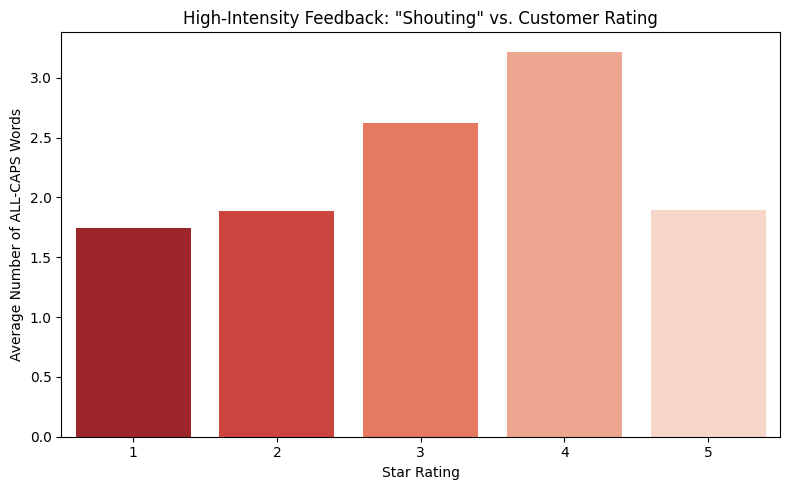

In [3]:
# 3. Calculate average intensity score by star rating
intensity_by_rating = df.groupby('rating')['intensity_score'].mean().reset_index()

print("Average All-Caps Words per Review by Rating:")
print(intensity_by_rating)

# 4. Visualize the correlation (Great for your presentation!)
plt.figure(figsize=(8, 5))
sns.barplot(data=intensity_by_rating, x='rating', y='intensity_score', palette='Reds_r')
plt.title('High-Intensity Feedback: "Shouting" vs. Customer Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average Number of ALL-CAPS Words')
plt.tight_layout()
plt.show() # or plt.savefig('intensity_chart.png')

In [4]:
# 1. Calculate the total number of words in each review
df['total_words'] = df['text'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)

# 2. Calculate the "Intensity Percentage" (All-Caps Words / Total Words)
# Adding a small number (0.0001) to avoid dividing by zero for empty reviews
df['intensity_percentage'] = (df['intensity_score'] / (df['total_words'] + 0.0001)) * 100

# 3. Check the new averages by rating
intensity_pct_by_rating = df.groupby('rating')['intensity_percentage'].mean().reset_index()

print("Percentage of Review in ALL-CAPS by Rating:")
print(intensity_pct_by_rating)

Percentage of Review in ALL-CAPS by Rating:
   rating  intensity_percentage
0       1              1.948968
1       2              1.474189
2       3              1.444097
3       4              1.379373
4       5              1.680708


/var/folders/xc/7907wjlx0h93vk1t9120tn9w0000gn/T/ipykernel_22377/1675555408.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=intensity_pct_by_rating, x='rating', y='intensity_percentage', palette='coolwarm_r')


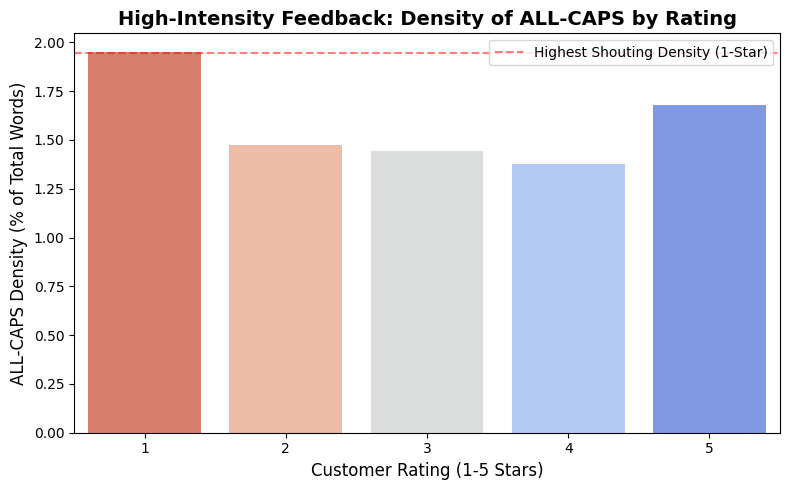

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'intensity_pct_by_rating' is the dataframe you just printed
plt.figure(figsize=(8, 5))

# Create a bar chart
sns.barplot(data=intensity_pct_by_rating, x='rating', y='intensity_percentage', palette='coolwarm_r')

# Make the chart look professional for the presentation
plt.title('High-Intensity Feedback: Density of ALL-CAPS by Rating', fontsize=14, fontweight='bold')
plt.xlabel('Customer Rating (1-5 Stars)', fontsize=12)
plt.ylabel('ALL-CAPS Density (% of Total Words)', fontsize=12)

# Highlight the 1-star bar to draw the executives' eyes to the problem
plt.axhline(y=1.948, color='red', linestyle='--', alpha=0.5, label='Highest Shouting Density (1-Star)')
plt.legend()

plt.tight_layout()
plt.show() # or plt.savefig('intensity_percentage_chart.png')